# **Curso IA desde Cero**

* Dr. Irvin Hussein López Nava
* M.C. Joan M. Raygoza Romero

# Preparar el conjunto de datos

## Librerias

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

## Cargar el conjunto de datos

In [2]:
df = pd.read_csv('emoevent_es.csv', sep="\t", encoding='utf-8')
print(df.shape)
df.head()

(8409, 4)


,id,tweet,emotion,offensive
0,1,Acabo de ver la gran pérdida que estamos tenie...,sadness,0
1,2,USER ¿A que vamos a reconstruir Notre Dame ant...,sadness,0
2,3,Desde ayer andan sufriendo por el incendio de ...,anger,0
3,4,Muy afectada -como muchísima gente- por lo ocu...,sadness,0
4,5,Es una mierda lo que paso en HASHTAG pero plea...,disgust,1


## Histograma de emociones

<Axes: >

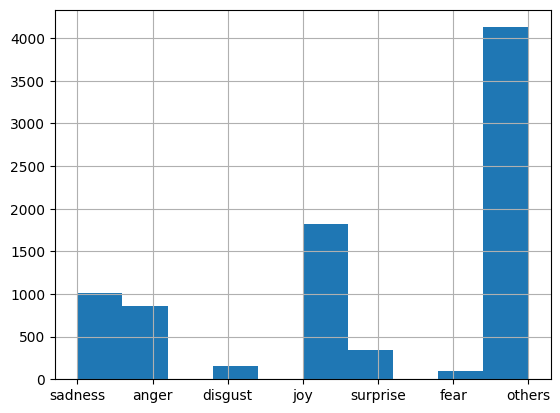

In [3]:
df['emotion'].hist()

In [4]:
df[df['emotion'] == 'others'].head()

,id,tweet,emotion,offensive
384,385,A propósito de la tragedia de HASHTAG URL,others,0
386,387,Además del patrimonio arquitectónico y cultura...,others,0
389,390,Cómo hacer que una tragedia se trate sobre mí ...,others,0
391,392,"""Convocaremos a los mejores talentos del mundo...",others,0
395,396,"Occidente esta en decadencia total, llena de c...",others,0


## Filtrar las emociones para quedarnos con las de interés (feliz, neutral, enojado, triste)

In [5]:
df = df[df["emotion"].isin(["joy", "others", "anger", "sadness"])]
df = df.replace("joy", "happy")
df = df.replace("others", "neutral")
df = df.replace("anger", "angry")
df = df.replace("sadness", "sad")

<Axes: >

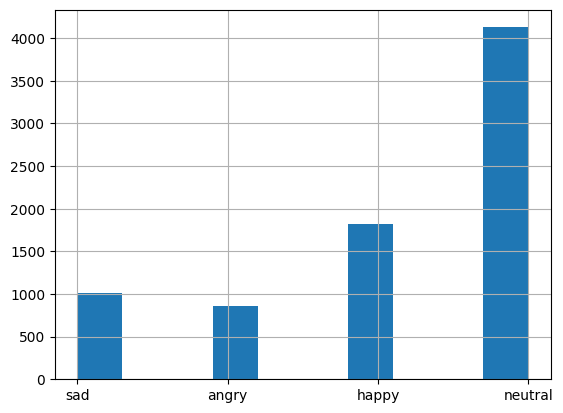

In [6]:
df['emotion'].hist()

## Extraer embeddings utilizando un transformer

In [7]:
# modelo ligero: "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# modelo mediano: "Qwen/Qwen3-Embedding-0.6B"
emb_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [8]:
embs = emb_model.encode(df['tweet'].values, batch_size=32, show_progress_bar=True)

Batches:   0%|          | 0/244 [00:00<?, ?it/s]

## Crear nuestro conjunto de datos

In [9]:
embeddings_df = pd.DataFrame(embs)
embeddings_df['emotion'] = df['emotion'].values
print(embeddings_df.shape)
embeddings_df.head()
embeddings_df.to_csv('embeddings.csv', index=False)

(7808, 1025)


# Haciendo nuestro modelo

## Librerias

In [10]:
from sklearn.model_selection import KFold,StratifiedKFold,GroupKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression


import matplotlib.pyplot as plt
import pickle
import seaborn as sns

## Leer el conjunto de datos

In [11]:
df = pd.read_csv('embeddings.csv')

## Preparar datos de entrada y salida

In [12]:
x = df.drop(['emotion'], axis=1).to_numpy()
le = LabelEncoder()
y = le.fit_transform(df['emotion'])

## Entrenamiento con validación cruzada

Fold 0: 0.6553532118690057
Fold 1: 0.6828894826890406
Fold 2: 0.6534412146683515
Fold 3: 0.6777666984468056
Fold 4: 0.6684599972481717
Mean F1 score macro: 0.6677834692980954
              precision    recall  f1-score   support

           0       0.66      0.46      0.54       857
           1       0.72      0.55      0.62      1815
           2       0.72      0.87      0.79      4127
           3       0.79      0.65      0.71      1009

    accuracy                           0.72      7808
   macro avg       0.72      0.63      0.67      7808
weighted avg       0.72      0.72      0.71      7808



Text(50.722222222222214, 0.5, 'True')

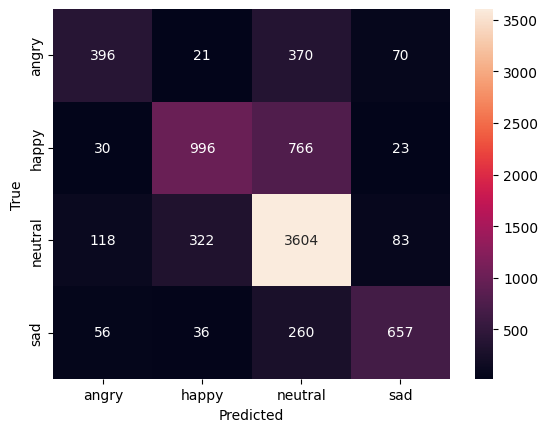

In [13]:
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
scores = []
conf_matrix = []
preds = []
true = []

for i, (train_index, test_index) in enumerate(kf.split(x,y)):
    x_train = x[train_index]
    x_test = x[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = LogisticRegression(max_iter=1000).fit(x_train, y_train)
    y_pred = model.predict(x_test)

    preds += list(y_pred)
    true += list(y_test)

    scores.append(f1_score(y_test, y_pred, average='macro'))
    matrix = confusion_matrix(y_test, y_pred)
    conf_matrix.append(matrix)

    print(f"Fold {i}: {scores[-1]}")
print(f"Mean F1 score macro: {f1_score(true, preds, average='macro')}")
print(classification_report(true, preds))
sns.heatmap(np.sum(conf_matrix, axis=0), annot=True, fmt='g', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

## Entrenar el modelo con todo el conjunto de datos y guardarlo junto con el label encoder

In [14]:
model = LogisticRegression(max_iter=1000).fit(x, y)

pickle.dump(model, open('text_model.pkl', 'wb'))
pickle.dump(le, open('text_le.pkl', 'wb'))

# Probar el modelo

## Instalar SpeechRecognition y pydub

In [15]:
!pip install SpeechRecognition pydub

## Función para grabar audio en colab

In [16]:
from google.colab import output
from base64 import b64decode
import io
from pydub import AudioSegment
import speech_recognition as sr

def grabar_audio():
    # JavaScript para grabar audio desde el navegador
    js = """
    const sleep = time => new Promise(resolve => setTimeout(resolve, time));
    const b64ToUint8Array = b64 => Uint8Array.from(atob(b64), c => c.charCodeAt(0));

    var record = true;

    async function recordAudio() {
      const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
      const mediaRecorder = new MediaRecorder(stream);
      let chunks = [];

      mediaRecorder.ondataavailable = e => chunks.push(e.data);
      mediaRecorder.start();

      // Botón para detener grabación
      const rec_btn = document.createElement('button');
      rec_btn.innerHTML = "⏺️ Detener grabación";
      rec_btn.style.fontSize = "20px";
      rec_btn.style.marginTop = "10px";
      document.body.appendChild(rec_btn);

      await new Promise(resolve => rec_btn.onclick = resolve);

      mediaRecorder.stop();
      await new Promise(resolve => mediaRecorder.onstop = resolve);

      const blob = new Blob(chunks);
      stream.getTracks().forEach(track => track.stop());
      const reader = new FileReader();
      reader.readAsDataURL(blob);

      return await new Promise(resolve => {
        reader.onloadend = () => resolve(reader.result.split(',')[1]);
      });
    }

    recordAudio();
    """

    # Ejecutar JS y obtener audio en base64
    audio_b64 = output.eval_js(js)

    # Convertir base64 a WAV en Python
    audio_bytes = b64decode(audio_b64)
    audio = AudioSegment.from_file(io.BytesIO(audio_bytes), format="webm")
    audio = audio.set_frame_rate(16000).set_channels(1)

    wav_io = io.BytesIO()
    audio.export(wav_io, format="wav")
    wav_io.seek(0)
    return wav_io

## Función para transcribir el audio

In [17]:
def transcribir_audio(wav_io):
    r = sr.Recognizer()

    with sr.AudioFile(wav_io) as source:
        audio = r.record(source)

    try:
        texto = r.recognize_google(audio, language="es-MX")
        print("✔️ Transcripción:")
        print(texto)
        return texto
    except Exception as e:
        print("❌ Error al transcribir:", str(e))


## Grabar audio, obtener el texto y usar el modelo

In [22]:
wav = grabar_audio()
text = transcribir_audio(wav)
embedding = emb_model.encode(text)
print("La emocion es:", le.inverse_transform(model.predict(embedding.reshape(1, -1)))[0])

✔️ Transcripción:
pues estoy muy contento porque presenté me dijeron que que muy buen trabajo
La emocion es: happy
